# Redo mapping of cell-types

In [29]:
# Load packages
suppressPackageStartupMessages(library(scran))
suppressPackageStartupMessages(library(scater))
suppressPackageStartupMessages(library(batchelor))
suppressPackageStartupMessages(library(parallel))


In [34]:
here::i_am("Mapping_redone/01_redo_mapping.ipynb")

# Load default settings
source(here::here("settings.R"))
source(here::here("utils.R"))

# Load mapping functions
source(here::here("rna/mapping/run/mnn/mapping_functions_extended.R"))

here() starts at /rds/project/rds-SDzz0CATGms/users/bt392/atlasses/gastrulation_multiome/code



In [18]:
args = list() 
# Query
args$query_metadata = '/rds/project/rds-SDzz0CATGms/users/bt392/atlasses/gastrulation_multiome/results/rna/doublet_detection/sample_metadata_after_doublets.txt.gz'
args$query_sce = '/rds/project/rds-SDzz0CATGms/users/bt392/atlasses/gastrulation_multiome/data/processed/rna/SingleCellExperiment.rds'
args$query_samples = c('E7.5_rep1','E7.5_rep2','E7.75_rep1','E8.0_rep1','E8.0_rep2','E8.5_rep1','E8.5_rep2','E8.75_rep1','E8.75_rep2')

# Atlas
args$atlas_sce = '/rds/project/rds-SDzz0CATGms/users/bt392/atlasses/gastrulation/pijuansala2019_gastrulation10x/processed/SingleCellExperiment.rds'
args$atlas_metadata = '/rds/project/rds-SDzz0CATGms/users/bt392/atlasses/gastrulation/pijuansala2019_gastrulation10x/sample_metadata_extended.txt.gz'
args$atlas_stages = c('7.25', 'E7.5', 'E7.75', 'E8.0', 'E8.25', 'E8.5')
args$npcs = 40
args$n_neighbours = 15
args$cosine_normalisation = FALSE

In [15]:
################
## Load query ##
################



# Load cell metadata
meta_query <- fread(args$query_metadata) %>% 
  .[pass_rnaQC==TRUE & doublet_call==FALSE & sample%in%args$query_samples]

# Load SingleCellExperiment
sce_query <- load_SingleCellExperiment(args$query_sce, cells = meta_query$cell, remove_non_expressed_genes = TRUE)

# Update colData
tmp <- meta_query %>% .[cell%in%colnames(sce_query)] %>% setkey(cell) %>% .[colnames(sce_query)]
stopifnot(tmp$cell == colnames(sce_query))
colData(sce_query) <- tmp %>% as.data.frame %>% tibble::column_to_rownames("cell") %>%
  .[colnames(sce_query),] %>% DataFrame()

In [ ]:
sce_query

class: SingleCellExperiment 
dim: 24031 52051 
metadata(0):
assays(1): counts
rownames(24031): Xkr4 Gm1992 ... CAAA01147332.1 AC149090.1
rowData names(0):
colnames(52051): E7.5_rep1#AAACAGCCAAACTCAT-1
  E7.5_rep1#AAACAGCCACAACCTA-1 ... E8.75_rep2#TTTGTTGGTTCACTGT-1
  E8.75_rep2#TTTGTTGGTTGAGCCG-1
colData names(11): barcode sample ... doublet_score doublet_call
reducedDimNames(0):
mainExpName: RNA
altExpNames(0):

In [19]:
################
## Load atlas ##
################

# Load cell metadata
meta_atlas <- fread(args$atlas_metadata) %>%
  .[stage%in%args$atlas_stages] %>%
  .[,sample:=factor(sample)] 

# Load SingleCellExperiment
sce_atlas <- load_SingleCellExperiment(args$atlas_sce, normalise = TRUE, cells = meta_atlas$cell, remove_non_expressed_genes = TRUE)

# Update colData
tmp <- meta_atlas %>% .[cell%in%colnames(sce_atlas)] %>% setkey(cell) %>% .[colnames(sce_atlas)]
stopifnot(tmp$cell == colnames(sce_atlas))
colData(sce_atlas) <- tmp %>% as.data.frame %>% tibble::column_to_rownames("cell") %>%
  .[colnames(sce_atlas),] %>% DataFrame()

# Sanity cehcks
stopifnot(sum(is.na(rownames(sce_atlas)))==0)
stopifnot(sum(duplicated(rownames(sce_atlas)))==0)

In [21]:
#####################
## Define gene set ##
#####################

# Get gene metadata
gene_metadata <- fread(io$gene_metadata) %>% .[,c("chr","ens_id","symbol", "description")] %>%
  .[symbol!="" & ens_id%in%rownames(sce_atlas)] %>%
  .[!duplicated(symbol)]

rownames(sce_atlas) = gene_metadata[match(rownames(sce_atlas), ens_id), symbol]

In [25]:
sce_atlas

class: SingleCellExperiment 
dim: 15507 75012 
metadata(1): log.exprs.offset
assays(2): counts logcounts
rownames(15507): Xkr4 Rp1 ... Hccs Mid1
rowData names(0):
colnames(75012): cell_361 cell_362 ... cell_139330 cell_139331
colData names(13): barcode sample ... index celltype_extended
reducedDimNames(0):
mainExpName: NULL
altExpNames(0):

In [24]:
# Imprinted genes
imprint = gene_metadata[c(grep('maternally', gene_metadata$description),
                       grep('paternally', gene_metadata$description)), symbol]
#Other imprinted genes: 
#- Nnat (https://www.genecards.org/cgi-bin/carddisp.pl?gene=NNAT)
#- Grb10 (https://www.genecards.org/cgi-bin/carddisp.pl?gene=GRB10)

# Intersect genes
genes.intersect <- intersect(rownames(sce_query), rownames(sce_atlas))

# Filter some genes manually
genes.intersect <- genes.intersect[grep("^Rik|Rik$|^mt-|^Rps|^Rpl|^Gm",genes.intersect,invert=T)] # filter out non-informative genes
genes.intersect <- genes.intersect[grep("^Hbb|^Hba",genes.intersect,invert=T)] # test removing Haem genes 
genes.intersect <- genes.intersect[!genes.intersect %in% c(imprint, 'Grb10', 'Nnat')] # remove imprinted genes
genes.intersect <- genes.intersect[!genes.intersect %in% c("Xist", "Tsix")] # remove Xist & Tsix
genes.intersect <- genes.intersect[!genes.intersect=="tomato-td"] # remove tomato itself
genes.intersect <- genes.intersect[!genes.intersect %in% gene_metadata[chr=="chrY",symbol]] # no genes on y-chr 

# Subset SingleCellExperiment objects
sce_query  <- sce_query[genes.intersect,]
sce_atlas <- sce_atlas[genes.intersect,]

In [26]:
#######################
## Feature selection ##
#######################

# Load gene statistics from the atlas
gene_stats.dt <- fread(paste0(io$atlas.basedir,"/results/gene_statistics/gene_statistics.txt.gz")) %>%
.[gene%in%genes.intersect]
genes_to_use <- gene_stats.dt %>% setorder(-var_pseudobulk, na.last = T) %>% head(n=2500) %>% .$gene  

stopifnot(genes_to_use%in%rownames(sce_atlas))
stopifnot(genes_to_use%in%rownames(sce_query))

sce_query = sce_query[genes_to_use,]
sce_atlas = sce_atlas[genes_to_use,]

In [15]:
sce_query
sce_atlas

class: SingleCellExperiment 
dim: 2500 56122 
metadata(0):
assays(1): counts
rownames(2500): Tdgf1 Hoxaas3 ... Cd93 Bdh2
rowData names(2): ENSEMBL SYMBOL
colnames(56122): cell_1 cell_2 ... cell_56121 cell_56122
colData names(6): barcode sample ... pool sizeFactor
reducedDimNames(1): pca.corrected
mainExpName: NULL
altExpNames(0):

class: SingleCellExperiment 
dim: 2500 75012 
metadata(1): log.exprs.offset
assays(2): counts logcounts
rownames(2500): Tdgf1 Hoxaas3 ... Cd93 Bdh2
rowData names(0):
colnames(75012): cell_361 cell_362 ... cell_139330 cell_139331
colData names(13): barcode sample ... index celltype_extended
reducedDimNames(0):
mainExpName: NULL
altExpNames(0):

In [35]:
mapping_full = mclapply(unique(meta_query$sample), function(x){
    mapping  <- mapWrap(
          sce_atlas = sce_atlas,
          meta_atlas = meta_atlas,
          sce_query = sce_query[,meta_query[sample==x, cell]],
          meta_query = meta_query[sample==x, ],
          genes = genes_to_use,
          npcs = args$npcs,
          k = args$n_neighbours,
          cosineNorm = args$cosine_normalisation,
          order = NULL
        )
    
    mapping.dt <- mapping$mapping %>% 
      .[,c("cell","celltype.mapped","celltype.score","celltype_extended.mapped","celltype_extended.score","stage.mapped", "cellstage.score", "closest.cell")] %>% 
      as.data.table
    
    return(mapping.dt)
}, mc.cores=9)

In [36]:
mapping_full = mapping_full %>% rbindlist()

In [37]:
head(mapping_full)

cell,celltype.mapped,celltype.score,celltype_extended.mapped,celltype_extended.score,stage.mapped,cellstage.score,closest.cell
<chr>,<chr>,<dbl>,<chr>,<dbl>,<chr>,<dbl>,<chr>
E7.5_rep1#AAACAGCCAAACTCAT-1,Primitive_Streak,0.5333333,Caudal_epiblast,0.6666667,E7.5,0.7333333,cell_46991
E7.5_rep1#AAACAGCCACAACCTA-1,ExE_ectoderm,1.0000000,ExE_ectoderm,1.0000000,E7.75,0.6666667,cell_43511
E7.5_rep1#AAACAGCCATCCTGAA-1,Nascent_mesoderm,0.7333333,Nascent_mesoderm,0.8666667,E7.5,0.9333333,cell_46801
E7.5_rep1#AAACAGCCATGCTATG-1,Primitive_Streak,0.9333333,Primitive_Streak,1.0000000,E7.5,0.9333333,cell_20376
E7.5_rep1#AAACATGCAACCTGGT-1,Parietal_endoderm,1.0000000,Parietal_endoderm,1.0000000,E7.5,0.7333333,cell_4248
E7.5_rep1#AAACATGCAATGAATG-1,Somitic_mesoderm,0.5333333,Intermediate_mesoderm,0.8666667,E7.5,0.5333333,cell_47867


In [38]:
meta_full = merge(meta_query, mapping_full, by='cell') %>% 
    .[match(colnames(sce_query), cell)]

In [49]:
fwrite(meta_full, 'meta_new_mapping.txt.gz')

In [50]:
umap = fread('/rds/project/rds-SDzz0CATGms/users/bt392/atlasses/gastrulation_multiome/results/rna_atac/mofa/pdf/batch_correction_False/umap.txt.gz')

In [52]:
umap_full = merge(meta_full, umap, by='cell')

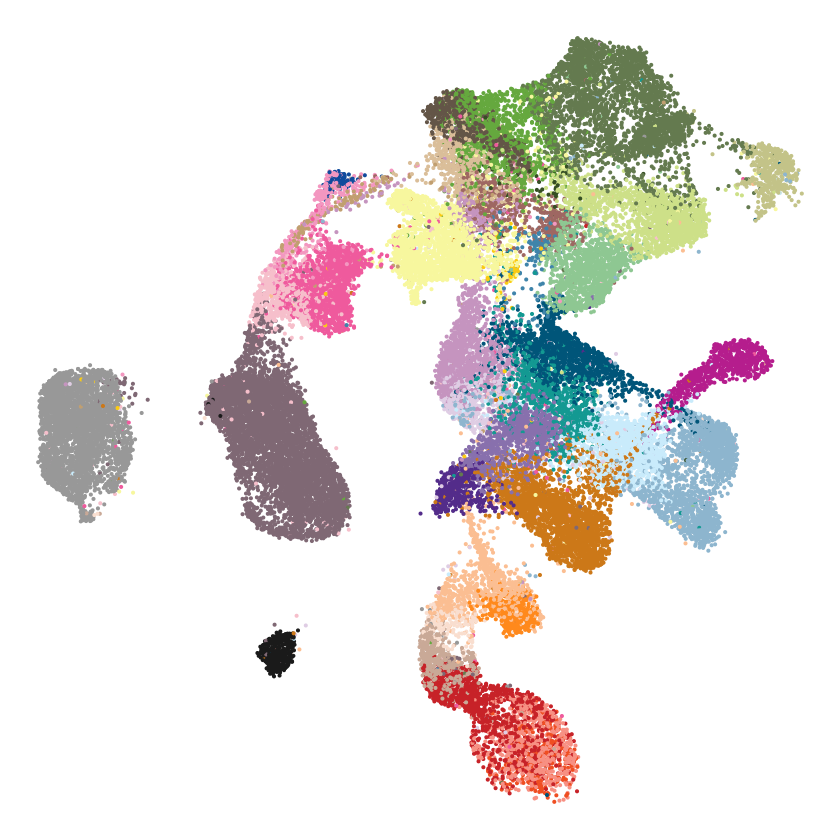

In [54]:
ggplot(umap_full, aes(V1, V2, color=celltype.mapped)) + 
    geom_point(size = 0.1) + 
    scale_color_manual(values = opts$celltype.colors) + 
    theme_void() + 
    theme(legend.position = 'none')

In [55]:
opts$celltype_extended.colors = c(
"Epiblast" = "#635547",
"Primitive_Streak" = "#DABE99",
"Caudal_epiblast" = "#9e6762",

"PGC" = "#FACB12",

"Anterior_Primitive Streak" = "#c19f70",
"Node"="#153b3d",
"Notochord" = "#0F4A9C",



"Gut_tube" = "#EF5A9D",
"Hindgut" = "#F397C0",
"Midgut" = "#ff00b2",
"Foregut" = "#ffb7ff",
"Pharyngeal_endoderm"="#95e1ff",
"Thyroid_primordium"="#97bad3",

"Nascent_mesoderm" = "#C594BF",
"Intermediate_mesoderm" = "#139992",
"Caudal_mesoderm" = "#3F84AA",
"Lateral_plate_mesoderm" = "#F9DFE6",
"Limb_mesoderm" = "#e35f82",
"Forelimb" = "#d02d75",
"Kidney_primordium" = "#e85639",
"Presomitic_mesoderm"="#5581ca",#"#0000ff",#blue
"Somitic_mesoderm" = "#005579",
"Posterior_somitic tissues" = "#5adbe4",#"#40e0d0",#turquoise



"Paraxial_mesoderm" = "#8DB5CE",
"Cranial_mesoderm" = "#456722",#"#006400",#darkgreen
"Anterior_somitic_tissues"= "#d5e839",
"Sclerotome" = "#e3cb3a",#"#ffff00",#yellow
"Dermomyotome" = "#00BFC4",#"#a52a2a",#brown



"Pharyngeal_mesoderm" = "#C9EBFB",
"Cardiopharyngeal_progenitors" = "#556789",
"Anterior_cardiopharyngeal_progenitors"="#683ed8",



"Allantois" = "#532C8A",
"Mesenchyme" = "#cc7818",
"YS_mesothelium" = "#ff7f9c",
"Epicardium"="#f79083",
"Embryo_proper_mesothelium" = "#ff487d",



"Cardiopharyngeal_progenitors_FHF"="#d780b0",
"Cardiomyocytes_FHF_1"="#a64d7e",
"Cardiomyocytes_FHF_2"="#B51D8D",



"Cardiopharyngeal_progenitors_SHF"="#4b7193",
"Cardiomyocytes_SHF_1"="#5d70dc",
"Cardiomyocytes_SHF_2"="#332c6c",



"Haematoendothelial_progenitors" = "#FBBE92",
"Blood_progenitors" = "#6c4b4c",
"Erythroid" = "#C72228",
"Chorioallantoic-derived_erythroid_progenitors"="#E50000",
"Megakaryocyte_progenitors"="#e3cb3a",
"MEP"="#EF4E22",
"EMP"="#7c2a47",



"YS_endothelium"="#ff891c",
"YS_mesothelium-derived_endothelial_progenitors"="#AE3F3F",
"Allantois_endothelium"="#2f4a60",
"Embryo_proper_endothelium"="#90e3bf",
"Venous_endothelium"="#bd3400",
"Endocardium"="#9d0049",

"NMPs_Mesoderm-biased" = "#89c1f5",
"NMPs" = "#8EC792",

"Ectoderm" = "#ff675c",



"Optic_vesicle" = "#bd7300",

"Ventral_forebrain_progenitors"="#a0b689",
"Early_dorsal_forebrain_progenitors"="#0f8073",
"Late_dorsal_forebrain_progenitors"="#7a9941",
"Midbrain_Hindbrain_boundary"="#8ab3b5",
"Midbrain_progenitors"="#9bf981",
"Dorsal_midbrain_neurons"="#12ed4c",
"Ventral_hindbrain_progenitors"="#7e907a",
"Dorsal_hindbrain_progenitors"="#2c6521",
"Hindbrain_floor_plate"="#bf9da8",
"Hindbrain_neural_progenitors"="#59b545",



"Neural_tube"="#233629",



"Migratory_neural_crest"="#4a6798",
"Branchial_arch_neural_crest"="#bd84b0",
"Frontonasal_mesenchyme"="#d3b1b1",



"Spinal_cord_progenitors"="#6b2035",
"Dorsal_spinal_cord_progenitors"="#e273d6",

"Non-neural_ectoderm" = "#f7f79e",
"Surface_ectoderm" = "#fcff00",
"Epidermis" = "#fff335",
"Limb_ectoderm" = "#ffd731",
"Amniotic_ectoderm" = "#dbb400",



"Placodal_ectoderm" = "#ff5c00",



"Otic_placode"="#f1a262",
"Otic_neural progenitors"="#00b000",

"Visceral_endoderm" = "#F6BFCB",
"ExE_endoderm" = "#7F6874",
"ExE_ectoderm" = "#989898",
"Parietal_endoderm" = "#1A1A1A"
)

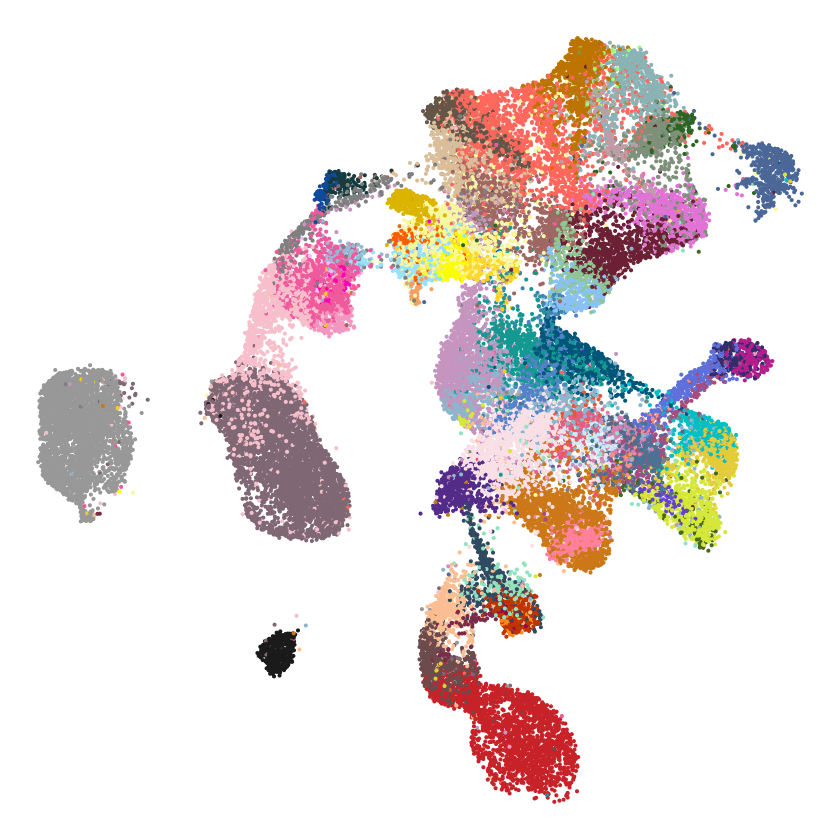

In [56]:
ggplot(umap_full, aes(V1, V2, color=celltype_extended.mapped)) + 
    geom_point(size = 0.1) + 
    scale_color_manual(values = opts$celltype_extended.colors) + 
    theme_void() + 
    theme(legend.position = 'none')